<p align="center">
• <a href="https://mayzune.com/"><strong>May Zune</strong></a> •
<a href="https://github.com/hellomayzune"><strong>GitHub</strong></a> •
<a href="https://orcid.org/0000-0003-0282-2633"><strong>ORCID</strong></a> •
<a href="https://scholar.google.com/citations?user=LmP8B_4AAAAJ&hl=en"><strong>Google Scholar</strong></a> •
<a href="https://www.researchgate.net/profile/May-Zune"><strong>ResearchGate</strong></a> •
<a href="https://www.linkedin.com/in/mayzune//"><strong>Linkedin</strong></a> •
</p>

# UKB Verisk Housing Archetype Analysis Using Mini-Batch K-Means

### Key Applications

* **Energy Efficiency and Retrofit Planning:** Identifies groups of properties with similar physical characteristics to support heat-loss modelling, retrofit prioritisation, and regional decarbonisation strategies.

* **Property Valuation and Risk Assessment:** Provides property archetypes that can be used as inputs for automated valuation models (AVMs), insurance risk analysis, and housing market assessment.

* **Urban and Infrastructure Planning:** Supports evidence-based planning by identifying residential density patterns and housing typologies, informing decisions on transport, utilities, EV charging infrastructure, and public services.


### Pipeline Stages

| Stage                 | Step(s) | Purpose                                                                                              |
| --------------------- | ------- | ---------------------------------------------------------------------------------------------------- |
| Environment & Setup   | 1       | Configure the analysis environment and dependencies                                                  |
| Data Loading          | 2       | Load the source dataset                                                                              |
| Feature Engineering   | 3       | Apply log transforms, age mapping, and missing-value handling                                        |
| Preprocessing         | 4       | Perform imputation, scaling, and one-hot encoding                                                    |
| K-Optimization        | 5       | Evaluate `K = 2–10` using the elbow method with a batch size of `4096`                               |
| Model Fitting         | 6       | Fit `MiniBatchKMeans` with `K = 6` and batch size `8192`                                             |
| Statistical Profiling | 7       | Calculate aggregated centroids and categorical modes                                                 |
| Visual Evaluation     | 8–12    | Assess cluster distribution, cohesion, spatial separation, feature profiles, and premise composition |

**Input, Output, Hyperparameters and Methods**

| **Pipeline Stage**       | **Core Input**              | **Primary Output**         | **Key Hyperparameters / Methods**                   |
| --------------------------------- | --------------------------- | -------------------------- | --------------------------------------------------- |
| **Preprocessing (Step 3–4)**     | Raw Dataset (`614,460 × 7`) | Matrix `X_processed`       | `StandardScaler`, `OneHotEncoder`, `log1p`          |
| **Model Optimization (Step 5)**   | Matrix `X_processed`        | Inertia vs. `K` Curve      | `MiniBatchKMeans`, `batch_size=4096`, `K ∈ [2, 10]` |
| **Model Fitting (Step 6)**        | Matrix `X_processed`        | Labels `archetype_cluster` | `MiniBatchKMeans`, `K=6`, `batch_size=8192`         |
| **Model Evaluation (Step 9–12)** | Sampled Matrix & Labels     | 4 Evaluation Plots         | Silhouette Coefficient (`0.38`), 2D PCA, Heatmaps   |


## Pipeline Overview

```text
[Step 1: Environment & Setup]
        │
        ▼
[Step 2: Data Loading]
        │
        ▼
[Step 3: Feature Engineering]
        └── Log Transforms, Age Mapping, Fill NAs
        │
        ▼
[Step 4: Preprocessing Pipeline]
        └── Imputation, Scaling, One-Hot Encoding
        │
        ▼
[Step 5: K-Optimization (Elbow)]
        └── Batch Size: 4096, K: 2 to 10
        │
        ▼
[Step 6: Model Fitting]
        └── MiniBatchKMeans, K = 6, Batch Size = 8192
        │
        ▼
[Step 7: Statistical Profiling]
        └── Aggregated Centroids & Categorical Modes
        │
        ▼
[Step 8–12: Visual Evaluation & Diagnostics]
        ├── Step 8: Archetype Distribution Bar Chart
        ├── Step 9: Silhouette Cohesion & Separation Plot
        ├── Step 10: 2D PCA Spatial Projection
        ├── Step 11: Standardized Feature Centroid Heatmap
        └── Step 12: Premise Type Composition Cross-Tabulation
```

In [1]:
# 1: Imports and Configuration
import os
import warnings

# MUST be set before importing sklearn / numpy / scipy
os.environ["OMP_NUM_THREADS"] = "8"
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.cluster._kmeans")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score

# Set plot style
sns.set_theme(style="whitegrid")
%matplotlib inline

In [2]:
# 2: Load Data
DATA_PATH = "CSV_UKBe16_Resi_SouthYorkshire-clean.csv"

df = pd.read_csv(DATA_PATH)
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (614460, 7)


,premise_age,premise_type,premise_floor_count,bungalow,height,building_area,gross_area
0,Post 1999,Semi-detached,2.0,Not a bungalow,10.2,245.2,490.4
1,1960-1979,Detached,1.0,Bungalow (high confidence),6.3,194.7,194.7
2,1990-1999,Detached,1.0,Bungalow (moderate confidence),7.1,128.1,128.1
3,1960-1979,Detached,1.0,Bungalow (moderate confidence),6.8,107.0,107.0
4,1990-1999,Detached,1.0,Bungalow (moderate confidence),4.9,98.7,98.7


In [3]:
# 3: Feature Engineering & Preprocessing Preparation
# 1. Map categorical construction age bands to numerical median years
age_mapping = {
    'Pre 1837': 1800,
    '1837-1869': 1853,
    '1870-1918': 1894,
    '1919-1944': 1931,
    '1945-1959': 1952,
    '1960-1979': 1970,
    '1980-1989': 1985,
    '1990-1999': 1995,
    'Post 1999': 2010,
    'Pre 1919': 1900,
    'Unknown date': np.nan
}

df['premise_age_num'] = df['premise_age'].map(age_mapping)

# 2. Clean missing values in categorical fields
df['bungalow_clean'] = df['bungalow'].fillna('Unknown')

# 3. Log-transform heavily skewed area metrics
df['log_building_area'] = np.log1p(df['building_area'])
df['log_gross_area'] = np.log1p(df['gross_area'])

# Feature groupings
num_features = ['premise_age_num', 'premise_floor_count', 'height', 'log_building_area', 'log_gross_area']
cat_features = ['premise_type', 'bungalow_clean']

print("Preprocessing complete.")

Preprocessing complete.


In [4]:
# 4: Construct Pipeline & Process Matrix
# Define transformations for numeric and categorical pipelines
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_features),
        ('cat', cat_transformer, cat_features)
    ]
)

# Fit and transform dataset
X_processed = preprocessor.fit_transform(df)
print(f"Processed feature matrix shape: {X_processed.shape}")

Processed feature matrix shape: (614460, 20)


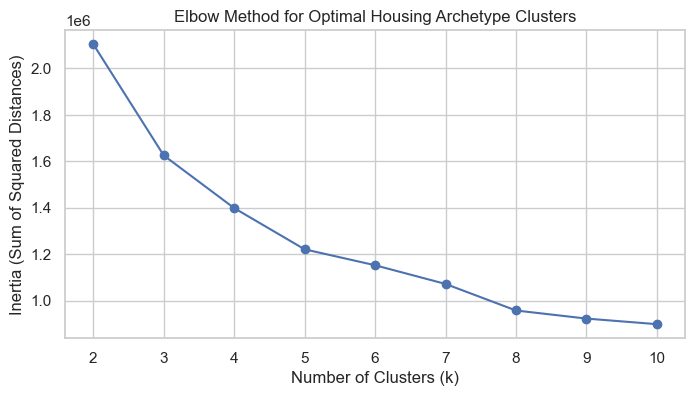

In [5]:
# 5: Optimal Cluster Selection (Elbow Method)
import os
import warnings

# Set environment variable to prevent MKL memory leak warning on Windows
os.environ["OMP_NUM_THREADS"] = "8"
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.cluster._kmeans")

inertia_list = []
k_range = range(2, 11)

# Increased batch_size to 4096 to prevent memory leak warning
for k in k_range:
    mbk = MiniBatchKMeans(
        n_clusters=k, 
        batch_size=4096, 
        random_state=42, 
        n_init="auto"
    )
    mbk.fit(X_processed)
    inertia_list.append(mbk.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia_list, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.title('Elbow Method for Optimal Housing Archetype Clusters')
plt.show()

In [6]:
# 6: Fit Final Model & Assign Clusters
OPTIMAL_K = 6  # Adjust based on the elbow plot elbow point

kmeans_model = MiniBatchKMeans(
    n_clusters=OPTIMAL_K, 
    batch_size=8192, 
    random_state=42, 
    n_init="auto"
)

df['archetype_cluster'] = kmeans_model.fit_predict(X_processed)
print("Cluster assignment completed.")

Cluster assignment completed.


In [7]:
# 7: Archetype Profiling & Feature Aggregation
# Calculate numerical averages per archetype cluster
cluster_summary = df.groupby('archetype_cluster').agg(
    count=('building_area', 'count'),
    mean_building_area=('building_area', 'mean'),
    median_building_area=('building_area', 'median'),
    mean_gross_area=('gross_area', 'mean'),
    mean_height=('height', 'mean'),
    mean_floors=('premise_floor_count', 'mean'),
    median_age=('premise_age_num', 'median')
).reset_index()

# Add dominant premise type and bungalow status per cluster
dominant_type = df.groupby('archetype_cluster')['premise_type'].agg(lambda x: x.mode()[0]).values
dominant_bungalow = df.groupby('archetype_cluster')['bungalow_clean'].agg(lambda x: x.mode()[0]).values

cluster_summary['dominant_premise_type'] = dominant_type
cluster_summary['dominant_bungalow_status'] = dominant_bungalow

cluster_summary

,archetype_cluster,count,mean_building_area,median_building_area,mean_gross_area,mean_height,mean_floors,median_age,dominant_premise_type,dominant_bungalow_status
0,0,113947,25.096552,21.2,20.541315,2.994920,1.008794,1952.0,Domestic outbuilding,Unknown
1,1,210728,134.907348,115.6,126.248174,8.214559,2.000066,1952.0,Semi-detached,Not a bungalow
2,2,87108,599.489935,422.1,137.834712,9.395200,2.072244,1894.0,Mid-terrace,Not a bungalow
3,3,62745,338.357954,252.8,250.370929,8.950437,2.613645,1970.0,Mid-terrace,Not a bungalow
4,4,105536,137.291237,108.4,183.611478,7.727642,2.009722,1995.0,Detached,Not a bungalow
5,5,34396,175.933138,134.1,102.313234,6.802887,1.003925,1970.0,Detached,Bungalow (high confidence)


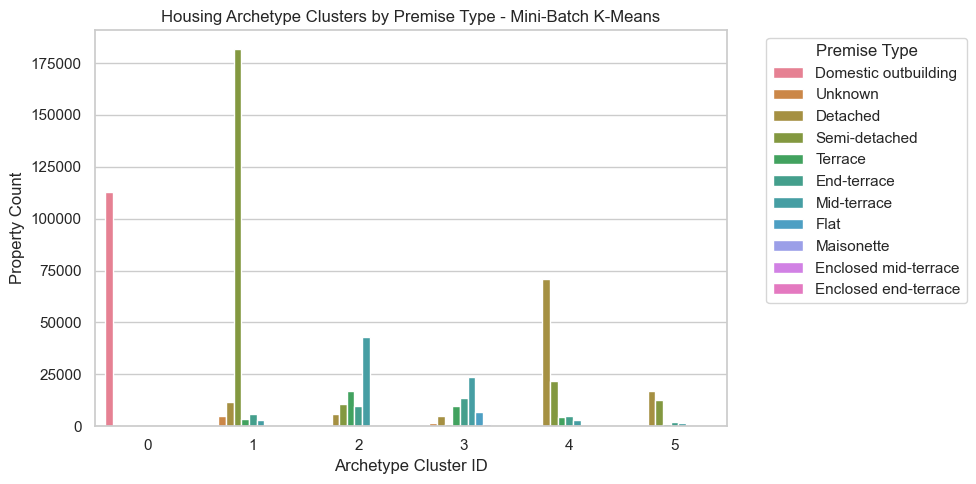

In [8]:
# 8: Archetype Distribution Visualization
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='archetype_cluster', hue='premise_type')
plt.title('Housing Archetype Clusters by Premise Type - Mini-Batch K-Means')
plt.xlabel('Archetype Cluster ID')
plt.ylabel('Property Count')
plt.legend(title='Premise Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Visual Evaluation Findings

1. **Outlier Separation (Cluster 0):** High silhouette values ($>0.75$) and distinct positioning in the PCA plot show complete isolation of non-domestic outbuildings from living units.

2. **Suburban/Domestic Overlap (Clusters 1 & 4):** The PCA scatter plot illustrates a smooth boundary transition between semi-detached homes (Cluster 1) and modern detached builds (Cluster 4).

3. **Density Transition (Cluster 3):** The negative tail in the Silhouette plot confirms Cluster 3 functions as a transitional archetype bridging Victorian terraces (Cluster 2) and modern mid-density developments.


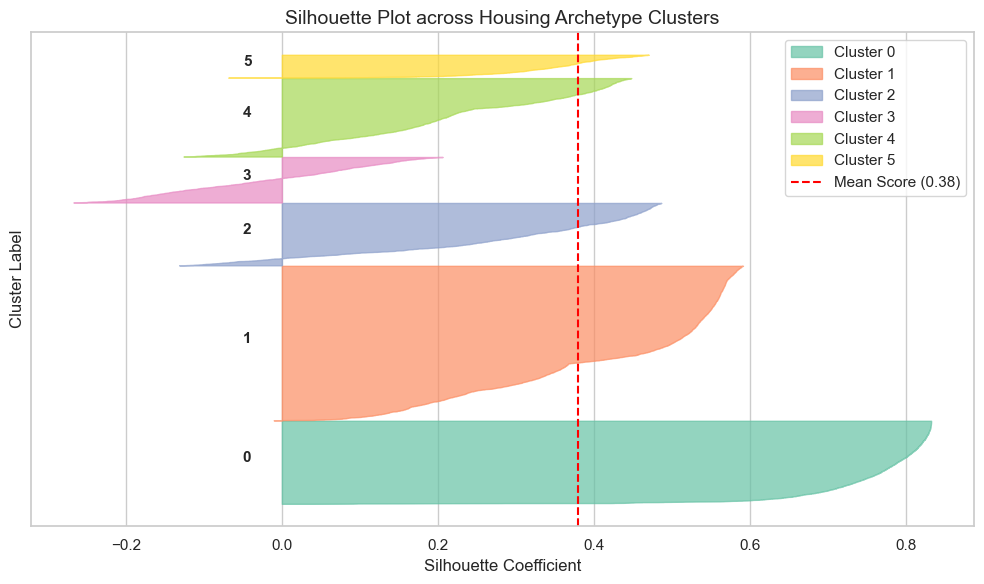

In [9]:
# 9: Silhouette Plot Analysis
from sklearn.metrics import silhouette_samples

# Sample 10,000 points for efficient silhouette computation
np.random.seed(42)
sample_idx = np.random.choice(X_processed.shape[0], size=10000, replace=False)
X_sample = X_processed[sample_idx]
labels_sample = df['archetype_cluster'].iloc[sample_idx].values

sil_vals = silhouette_samples(X_sample, labels_sample)
avg_sil = sil_vals.mean()

fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 10
colors = sns.color_palette("Set2", OPTIMAL_K)

for i in range(OPTIMAL_K):
    ith_cluster_sil_values = sil_vals[labels_sample == i]
    ith_cluster_sil_values.sort()
    size_cluster_i = ith_cluster_sil_values.shape[0]
    y_upper = y_lower + size_cluster_i

    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        ith_cluster_sil_values,
        facecolor=colors[i],
        edgecolor=colors[i],
        alpha=0.7,
        label=f'Cluster {i}'
    )
    ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i), fontsize=11, fontweight='bold')
    y_lower = y_upper + 10

ax.axvline(x=avg_sil, color="red", linestyle="--", label=f'Mean Score ({avg_sil:.2f})')
ax.set_title("Silhouette Plot across Housing Archetype Clusters", fontsize=14)
ax.set_xlabel("Silhouette Coefficient")
ax.set_ylabel("Cluster Label")
ax.set_yticks([])
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

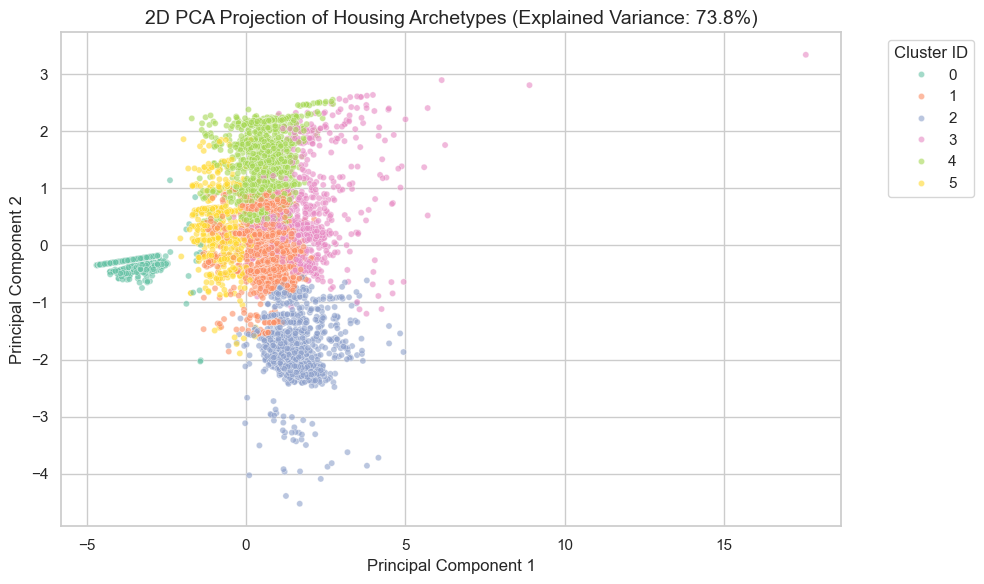

In [10]:
# 10: PCA 2D Cluster Separation Plot
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_sample)
explained_var = pca.explained_variance_ratio_.sum() * 100

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=X_pca[:, 0], 
    y=X_pca[:, 1], 
    hue=labels_sample, 
    palette="Set2", 
    alpha=0.6, 
    s=20, 
    legend='full'
)
plt.title(f"2D PCA Projection of Housing Archetypes (Explained Variance: {explained_var:.1f}%)", fontsize=14)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster ID", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

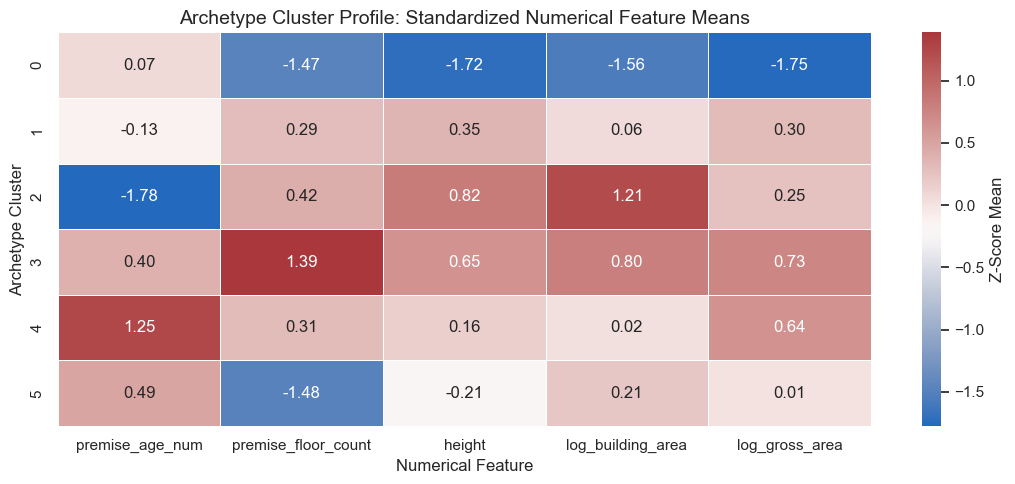

In [11]:
# 11: Standardized Feature Centroid Profile Heatmap
feature_names = preprocessor.get_feature_names_out()
df_processed = pd.DataFrame(X_processed, columns=feature_names)
df_processed['cluster'] = df['archetype_cluster'].values

# Extract standardized numerical feature centroids
num_cols = [c for c in df_processed.columns if c.startswith('num__')]
centroid_df = df_processed.groupby('cluster')[num_cols].mean()

# Rename columns for clarity
centroid_df.columns = [c.replace('num__', '') for c in centroid_df.columns]

plt.figure(figsize=(11, 5))
sns.heatmap(
    centroid_df, 
    cmap='vlag', 
    annot=True, 
    fmt='.2f', 
    linewidths=.5, 
    cbar_kws={'label': 'Z-Score Mean'}
)
plt.title("Archetype Cluster Profile: Standardized Numerical Feature Means", fontsize=14)
plt.xlabel("Numerical Feature")
plt.ylabel("Archetype Cluster")
plt.tight_layout()
plt.show()

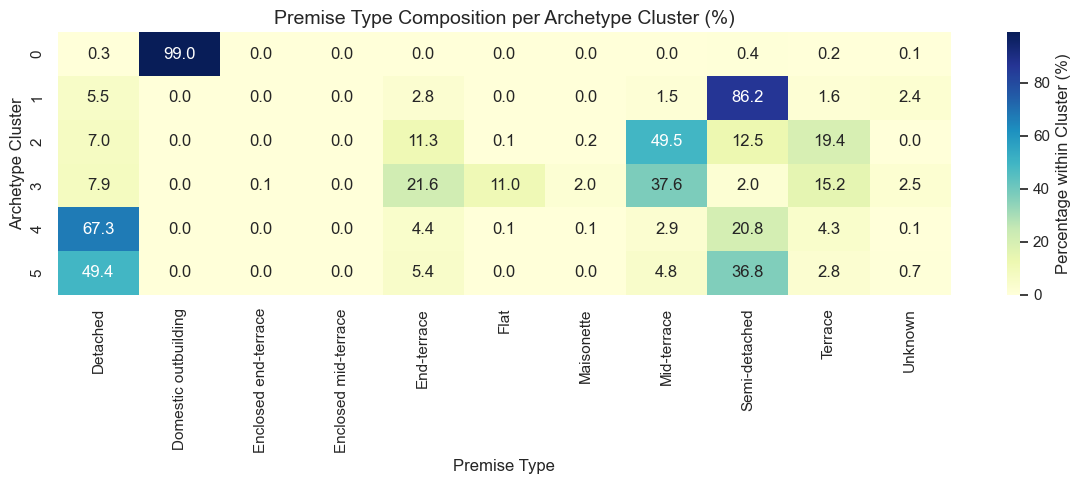

In [12]:
# 12: Categorical Cross-Tabulation Heatmap
crosstab_pct = pd.crosstab(
    df['archetype_cluster'], 
    df['premise_type'], 
    normalize='index'
) * 100

plt.figure(figsize=(12, 5))
sns.heatmap(
    crosstab_pct, 
    annot=True, 
    fmt='.1f', 
    cmap='YlGnBu', 
    cbar_kws={'label': 'Percentage within Cluster (%)'}
)
plt.title("Premise Type Composition per Archetype Cluster (%)", fontsize=14)
plt.xlabel("Premise Type")
plt.ylabel("Archetype Cluster")
plt.tight_layout()
plt.show()

## Methods Details

### Phase 1: Environment Setup and Data Ingestion

#### Step 1 — Environment and Imports Configuration

The computational environment was configured to support efficient execution of the clustering workflow. Multi-threading was enabled through the `OMP_NUM_THREADS` environment variable, set to **8 threads**, while OpenMP/MKL warnings were suppressed to mitigate potential memory-management issues associated with multi-threaded execution on Windows. The analysis environment was then populated with the required libraries for data manipulation, machine learning, statistical analysis, and visualisation, including `pandas`, `scikit-learn`, `matplotlib`, and `seaborn`.

#### Step 2 — Data Ingestion

The cleaned South Yorkshire residential dataset, `CSV_UKBe16_Resi_SouthYorkshire-clean.csv`, was loaded for analysis. The dataset contained **614,460 observations and seven initial features**, providing the input data for subsequent feature engineering, preprocessing, and clustering.

---

### Step 2: Feature Engineering and Preprocessing

#### Step 3 — Feature Engineering

Several transformations were applied to improve the suitability of the input variables for clustering:

* **Property age conversion:** The categorical `premise_age` bands were converted into numerical values representing estimated midpoint construction years. This allowed property age to be incorporated as a continuous numerical feature.
* **Area transformation:** `building_area` and `gross_area` were transformed using the natural logarithm, `ln(1+x)`, to reduce the influence of highly right-skewed property-size distributions.
* **Missing categorical values:** Missing entries in the `bungalow` variable were assigned the category `"Unknown"` to ensure that observations were retained during preprocessing.

#### Step 4 — Preprocessing Pipeline

A `ColumnTransformer` was constructed to apply separate preprocessing procedures to numerical and categorical variables.

The **numerical pipeline** used median imputation to replace missing values, followed by `StandardScaler` to standardise the variables to approximately zero mean and unit variance. The **categorical pipeline** applied constant imputation using `"Unknown"` and subsequently transformed categorical variables, including `premise_type` and `bungalow_clean`, using one-hot encoding.

The resulting transformed feature matrix, `X_processed`, provided the standardised input for clustering.

---

### Step 3: Model Optimisation and Clustering

#### Step 5 — Optimal Cluster Selection

The appropriate number of clusters was assessed using the **elbow method**. `MiniBatchKMeans` models were evaluated across values of **K = 2–10**, using a batch size of **4,096**. For each candidate solution, the within-cluster sum of squares (inertia) was calculated.

The resulting inertia values were examined to identify the point at which increasing the number of clusters produced diminishing improvements in within-cluster compactness. This analysis supported the selection of **six clusters** for the final model.

#### Step 6 — Final Model Training and Cluster Assignment

The final clustering model was fitted using `MiniBatchKMeans` with:

* **Number of clusters:** `K = 6`
* **Batch size:** `8,192`

The model was trained using the processed feature matrix, `X_processed`. Each observation was subsequently assigned to its corresponding cluster, with the resulting labels stored in the primary dataset under the `archetype_cluster` variable.

---

### Phase 4: Cluster Profiling and Visual Evaluation

#### Step 7 — Archetype Profiling and Statistical Summary

The six clusters were statistically profiled to determine their defining characteristics. Cluster-level summaries included:

* Number of observations within each cluster.
* Mean and median values for continuous variables.
* Dominant categorical values for `premise_type` and `bungalow_status`.

These summaries provided the basis for interpreting the statistical characteristics of each cluster and assigning meaningful residential archetype descriptions, such as **Victorian Terraces, Inter-War Semis, and Outbuildings**.

#### Step 8 — Property Distribution Visualisation

A count-based visualisation was produced to examine the distribution of property types across the six clusters. This provided an overview of cluster size and highlighted differences in the composition of property types between archetypes.

#### Step 9 — Silhouette Analysis

Cluster cohesion and separation were assessed using a silhouette analysis. A random sample of **10,000 observations** was selected from `X_processed`, and individual silhouette coefficients were calculated using `silhouette_samples`.

The resulting plot displayed silhouette widths for individual observations within each cluster and was compared against the overall mean silhouette score of **0.38**. This diagnostic was used to identify clusters with strong internal cohesion, as well as observations that may occupy ambiguous or overlapping regions between clusters.

#### Step 10 — Principal Component Analysis

Principal Component Analysis (PCA) was used to project the high-dimensional processed feature space into two dimensions for visual assessment. The first two principal components accounted for **73.8% of the total variance**.

The resulting scatter plot provided a geometric representation of the six clusters, allowing the degree of cluster separation, overlap, and transitional structure to be assessed visually.

#### Step 11 — Standardised Feature Centroid Heatmap

A centroid heatmap was generated using standardised numerical feature means for each cluster. The resulting Z-score representation enabled direct comparison of the relative feature profiles of the six archetypes.

Positive and negative deviations from the overall mean highlighted the structural characteristics that distinguished individual clusters.

#### Step 12 — Categorical Composition Analysis

A normalised cross-tabulation was constructed between `archetype_cluster` and `premise_type`. The resulting percentage heatmap quantified the composition of each cluster in terms of property type.

This analysis complemented the numerical centroid analysis by identifying the categorical characteristics most strongly associated with each residential archetype.


## Limitations

### 1. Feature Engineering and Preprocessing

* **Age-band approximations:** Converting broad or open-ended construction-age categories into single midpoint years introduces artificial precision and may distort true temporal relationships, particularly for historical and unknown-age properties.
* **Categorical distance distortion:** One-hot encoding categorical variables causes `K-Means` to treat binary category differences alongside continuous feature differences under the same Euclidean distance metric. This may create cluster boundaries driven disproportionately by categorical attributes.
* **Log-transformation effects:** Applying `log1p` reduces the influence of extreme property sizes but also compresses differences between larger properties, potentially masking important variation among large buildings and estates.

### 2. Clustering Algorithm Constraints

* **Spherical cluster assumption:** `MiniBatchKMeans` assumes relatively compact, convex, and similarly sized clusters, whereas residential properties may form irregular, overlapping, or hierarchical patterns.
* **Forced outlier assignment:** `K-Means` does not explicitly identify noise. Extreme observations, such as unusually large buildings or anomalous height values, are therefore assigned to existing clusters and may influence their centroids.
* **Mini-batch approximation:** Using `MiniBatchKMeans` improves computational efficiency for the **614,460-record dataset**, but the stochastic mini-batch process may produce slightly less precise centroids than full-batch `K-Means`.
* **Fixed number of clusters:** Selecting **K = 6** imposes a rigid partition on a continuous housing landscape. Smaller architectural groups may therefore be absorbed into larger clusters rather than forming distinct archetypes.

### 3. Evaluation and Visualisation

* **Silhouette analysis:** The silhouette score was calculated using a sample of **10,000 observations**, which may introduce sampling variation and underrepresent low-frequency property types.
* **PCA projection:** The two-dimensional PCA visualisation captures **73.8% of the variance**, meaning **26.2% remains outside the visualisation**. Consequently, apparent overlap in two dimensions may not fully represent separation in the original feature space.
* **Cluster heatmaps:** Aggregated means and dominant categorical proportions can conceal substantial within-cluster variation, skewness, or multiple sub-groups within individual archetypes.

### 4. Potential Methodological Improvements

Future iterations could address these limitations through:

1. **Mixed-distance clustering:** Use **K-Prototypes** or **Gower distance with medoid-based clustering** to better handle mixed numerical and categorical data.
2. **Density-based methods:** Combine **UMAP** with **HDBSCAN** to capture non-linear cluster structures and explicitly identify outliers as noise.
3. **Probabilistic clustering:** Apply **Latent Class Analysis (LCA)** or **Gaussian Mixture Models (GMM)** to provide soft cluster-membership probabilities rather than forcing each property into a single archetype.

## Real-World Application

The **Mini-Batch K-Means clustering pipeline** provides a scalable approach for segmenting large built-environment datasets into meaningful structural archetypes. Its main real-world applications include:

### Core Applications

* **Built Environment and GIS Analytics:** Segments large property databases into distinct physical profiles based on characteristics such as age, height, footprint, and property type.
* **Energy Efficiency and Retrofit Planning:** Groups properties with similar physical characteristics to support heat-loss estimation, retrofit cost modelling, and regional decarbonisation strategies.
* **Property Valuation and Risk Assessment:** Provides structural features that can support Automated Valuation Models (AVMs), insurance risk profiling, and property classification.
* **Urban Infrastructure Planning:** Identifies differences between high-density and low-density residential areas to inform planning for EV charging, water demand, waste collection, and other infrastructure requirements.

### Suitability of the Method

| **Criterion**            | **Applicability**                                                                                                                     |
| ------------------------ | ------------------------------------------------------------------------------------------------------------------------------------- |
| **Dataset Scale**        | Well suited to large datasets (**>100,000 records**) because Mini-Batch K-Means provides computationally efficient clustering.        |
| **Data Structure**       | Most effective when clusters are relatively compact and well separated within a standardised feature space.                           |
| **Analytical Objective** | Particularly useful for **exploratory segmentation** and establishing baseline property archetypes before more specialised modelling. |

### When Alternative Methods Are Preferable

* **Complex cluster structures:** **UMAP + HDBSCAN** is better suited to non-spherical clusters, irregular spatial structures, and explicit outlier detection.
* **Mixed numerical and categorical data:** **K-Prototypes** or **Latent Class Analysis (LCA)** can provide more appropriate treatment when categorical variables strongly influence the clustering.
* **Overlapping property types:** **Gaussian Mixture Models (GMM)** are preferable when properties may belong to multiple archetypes and probabilistic membership is required.

### Overall Application

The pipeline is therefore most valuable as a **rapid, scalable baseline for large-scale property segmentation**. The resulting archetypes can provide an interpretable foundation for downstream applications in **energy modelling, property valuation, infrastructure planning, risk assessment, and urban policy**.
